# Univariate Testing For All Architecture 
This notebook mean to see what if using univariate feature for Seasonal Naive, XGBoost, RNN, and LSTM how good all architecture perform for predict sales

## Import Libraries

In [30]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_log_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import time

SEED = 10122097
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [31]:
# Make a specific store and family
scenarios = [
    (44, 'GROCERY I'),
    (44, 'LAWN AND GARDEN'),
    (44, 'HARDWARE')
]
TIME_STEPS = 14

In [32]:
# Loading data into notebook
train = pd.read_csv("datasets/train.csv", parse_dates=['date'])
test = pd.read_csv("datasets/test.csv", parse_dates=['date'])
oil = pd.read_csv("datasets/oil.csv", parse_dates=['date'])
holidays = pd.read_csv("datasets/holidays_events.csv", parse_dates=['date'])
stores = pd.read_csv("datasets/stores.csv")
transactions = pd.read_csv("datasets/transactions.csv", parse_dates=['date'])

In [33]:
def create_sequences(data, time_steps=14):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    # Ensure no negative predictions for RMSLE
    y_pred = np.maximum(y_pred, 0)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    return mae, rmsle



Processing Store: 44, Family: GROCERY I
Seasonal Naive - MAE: 1255.0333, RMSLE: 0.1586
XGBoost        - MAE: 942.0731, RMSLE: 0.1289
Simple RNN     - MAE: 778.9728, RMSLE: 0.1011
LSTM           - MAE: 1171.8420, RMSLE: 0.1344


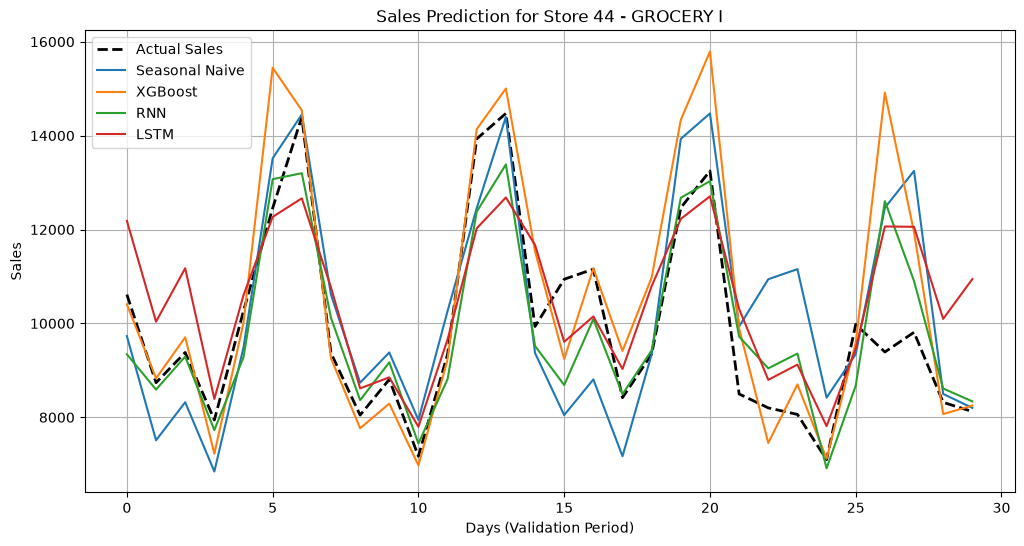


Processing Store: 44, Family: LAWN AND GARDEN
Seasonal Naive - MAE: 11.7667, RMSLE: 0.5424
XGBoost        - MAE: 8.3238, RMSLE: 0.3765
Simple RNN     - MAE: 9.0245, RMSLE: 0.3982
LSTM           - MAE: 8.0144, RMSLE: 0.3501


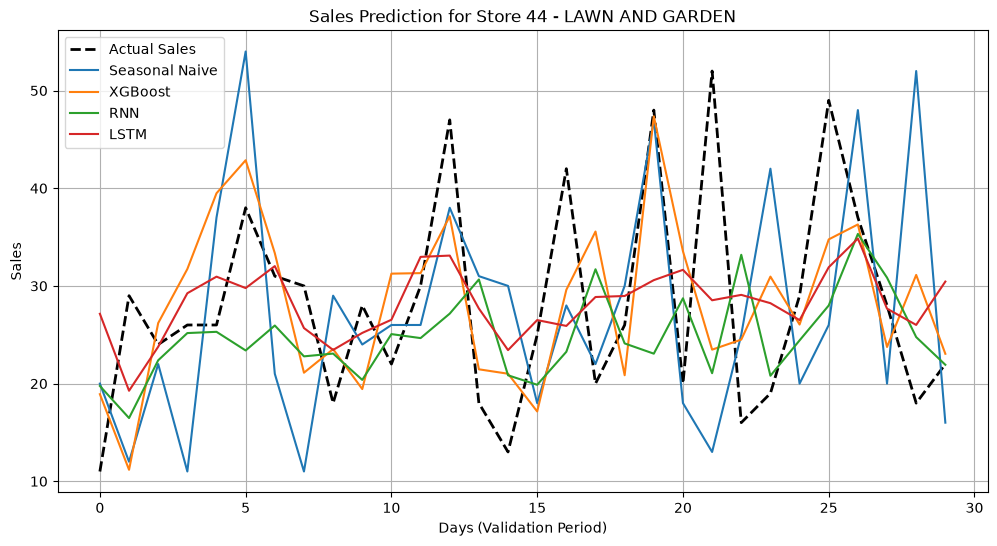


Processing Store: 44, Family: HARDWARE
Seasonal Naive - MAE: 2.7667, RMSLE: 0.7056
XGBoost        - MAE: 2.8412, RMSLE: 0.6554
Simple RNN     - MAE: 2.2309, RMSLE: 0.5447
LSTM           - MAE: 2.2528, RMSLE: 0.5416


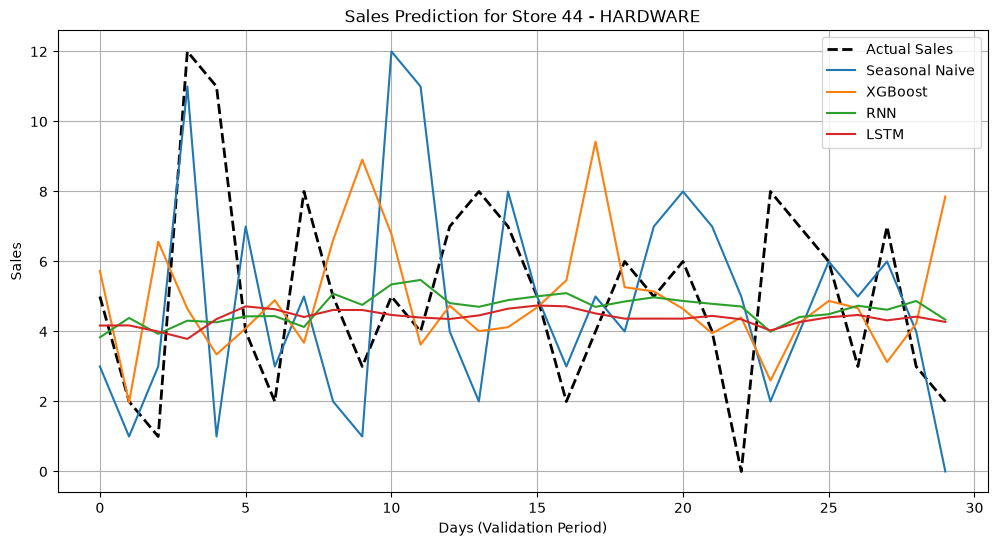

In [34]:
results = []

for (store, family) in scenarios:
    print(f"\n{'='*50}")
    print(f"Processing Store: {store}, Family: {family}")
    print(f"{'='*50}")
    
    # 1. Filter Data
    df_store = train[(train['store_nbr'] == store) & (train['family'] == family)].copy()
    df_store = df_store.sort_values('date')
    
    # We only use 'sales' for univariate forecasting
    sales_data = df_store['sales'].values.reshape(-1, 1)
    
    # Train-test split (e.g., last 30 days as validation)
    val_size = 30
    train_data = sales_data[:-val_size]
    val_data = sales_data[-val_size:]
    
    # Scale Data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    val_scaled = scaler.transform(val_data)
    
    # Create sequences
    X_train, y_train = create_sequences(train_scaled, TIME_STEPS)
    
    # Ensure validation sequence matches validation target length (30 days)
    # We need to prepend the last TIME_STEPS from train to validation set
    combined_val_data = np.vstack((train_scaled[-TIME_STEPS:], val_scaled))
    X_val, y_val = create_sequences(combined_val_data, TIME_STEPS)
    
    # Actual unscaled y_val for metric calculation
    y_val_unscaled = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    
    # ---------------------------------------------------------
    # 1. Seasonal Naive
    # Using the value from 7 days ago as prediction
    # ---------------------------------------------------------
    seasonality = 7
    y_pred_naive = np.zeros(len(val_data))
    combined_naive = np.vstack((train_data[-seasonality:], val_data))
    for i in range(len(val_data)):
        y_pred_naive[i] = combined_naive[i, 0] # 7 days ago relative to i+seasonality
    
    mae_naive, rmsle_naive = calculate_metrics(y_val_unscaled, y_pred_naive)
    print(f"Seasonal Naive - MAE: {mae_naive:.4f}, RMSLE: {rmsle_naive:.4f}")
    
    # ---------------------------------------------------------
    # 2. XGBoost (using lagged features)
    # ---------------------------------------------------------
    # Flatten X for XGBoost: (samples, time_steps)
    X_train_xgb = X_train.reshape((X_train.shape[0], X_train.shape[1]))
    X_val_xgb = X_val.reshape((X_val.shape[0], X_val.shape[1]))
    
    xgb_model = XGBRegressor(n_estimators=100, random_state=SEED)
    xgb_model.fit(X_train_xgb, y_train.flatten())
    
    y_pred_xgb_scaled = xgb_model.predict(X_val_xgb)
    y_pred_xgb = scaler.inverse_transform(y_pred_xgb_scaled.reshape(-1, 1)).flatten()
    
    mae_xgb, rmsle_xgb = calculate_metrics(y_val_unscaled, y_pred_xgb)
    print(f"XGBoost        - MAE: {mae_xgb:.4f}, RMSLE: {rmsle_xgb:.4f}")
    
    # ---------------------------------------------------------
    # 3. Simple RNN
    # ---------------------------------------------------------
    rnn_model = Sequential([
        Input(shape=(TIME_STEPS, 1)),
        SimpleRNN(64, activation='relu'),
        Dense(1)
    ])
    rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    rnn_model.fit(X_train, y_train, epochs=30, batch_size=32, 
                  validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    
    y_pred_rnn_scaled = rnn_model.predict(X_val, verbose=0)
    y_pred_rnn = scaler.inverse_transform(y_pred_rnn_scaled).flatten()
    
    mae_rnn, rmsle_rnn = calculate_metrics(y_val_unscaled, y_pred_rnn)
    print(f"Simple RNN     - MAE: {mae_rnn:.4f}, RMSLE: {rmsle_rnn:.4f}")
    
    # ---------------------------------------------------------
    # 4. LSTM
    # ---------------------------------------------------------
    lstm_model = Sequential([
        Input(shape=(TIME_STEPS, 1)),
        LSTM(64, activation='relu'),
        Dense(1)
    ])
    lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    lstm_model.fit(X_train, y_train, epochs=30, batch_size=32, 
                   validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    
    y_pred_lstm_scaled = lstm_model.predict(X_val, verbose=0)
    y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled).flatten()
    
    mae_lstm, rmsle_lstm = calculate_metrics(y_val_unscaled, y_pred_lstm)
    print(f"LSTM           - MAE: {mae_lstm:.4f}, RMSLE: {rmsle_lstm:.4f}")
    
    # Store results
    results.append({
        'Store': store,
        'Family': family,
        'Naive_MAE': mae_naive, 'Naive_RMSLE': rmsle_naive,
        'XGB_MAE': mae_xgb, 'XGB_RMSLE': rmsle_xgb,
        'RNN_MAE': mae_rnn, 'RNN_RMSLE': rmsle_rnn,
        'LSTM_MAE': mae_lstm, 'LSTM_RMSLE': rmsle_lstm
    })
    
    # Plotting predictions
    plt.figure(figsize=(12, 6))
    plt.plot(y_val_unscaled, label='Actual Sales', linestyle='--', color='black', linewidth=2)
    plt.plot(y_pred_naive, label='Seasonal Naive')
    plt.plot(y_pred_xgb, label='XGBoost')
    plt.plot(y_pred_rnn, label='RNN')
    plt.plot(y_pred_lstm, label='LSTM')
    plt.title(f"Sales Prediction for Store {store} - {family}")
    plt.xlabel("Days (Validation Period)")
    plt.ylabel("Sales")
    plt.grid(True)
    plt.legend()
    plt.show()


In [35]:
# Summarize Results
results_df = pd.DataFrame(results)
display(results_df)


,Store,Family,Naive_MAE,Naive_RMSLE,XGB_MAE,XGB_RMSLE,RNN_MAE,RNN_RMSLE,LSTM_MAE,LSTM_RMSLE
0,44,GROCERY I,1255.033333,0.158615,942.073128,0.128868,778.972835,0.101133,1171.841960,0.134367
1,44,LAWN AND GARDEN,11.766667,0.542367,8.323768,0.376530,9.024514,0.398210,8.014426,0.350097
2,44,HARDWARE,2.766667,0.705557,2.841206,0.655431,2.230887,0.544733,2.252826,0.541641
